In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

df = pd.read_excel('/content/Layer24_1000_Row_Advanced_Dataset.xlsx')
df.head()

,User_ID,Mood,Stress_Level,Energy_Level,Sleep_Hours,Task_Name,Task_Layer,Task_Type,Task_Difficulty,Priority,Time_Required_Hours,Deadline,Total_Day_Load_Hours,Overloaded,Mood_Impact,Suggested_Action,Reason
0,1,Anxious,10,6,5.5,Photography,Hobby,Wellness,1,1,3.0,7,24.0,No,Positive,Keep,Supports mental wellness
1,2,Anxious,7,5,5.0,Festival Preparation,Social,Optional,2,2,4.5,2,21.5,No,Neutral,Keep,Important for productivity
2,3,Relaxed,2,9,7.5,Stretching,Health,Wellness,5,1,4.0,1,26.5,Yes,Neutral,Keep,Helps maintain balance
3,4,Happy,1,9,8.0,Instagram Scrolling,Entertainment,Optional,4,3,0.5,1,32.0,Yes,Negative,Keep,Supports mental wellness
4,5,Exhausted,8,4,4.0,Taking Medicines,Personal,Essential,4,2,2.0,Routine,32.0,Yes,Neutral,Keep,Supports mental wellness


In [2]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])

X = df.drop('Suggested_Action', axis=1)
y = df['Suggested_Action']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Model Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 0.975
Model Accuracy: 97.5 %


In [3]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

[[ 17   2   0]
 [  3 144   0]
 [  0   0  34]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87        19
           1       0.99      0.98      0.98       147
           2       1.00      1.00      1.00        34

    accuracy                           0.97       200
   macro avg       0.95      0.96      0.95       200
weighted avg       0.98      0.97      0.98       200



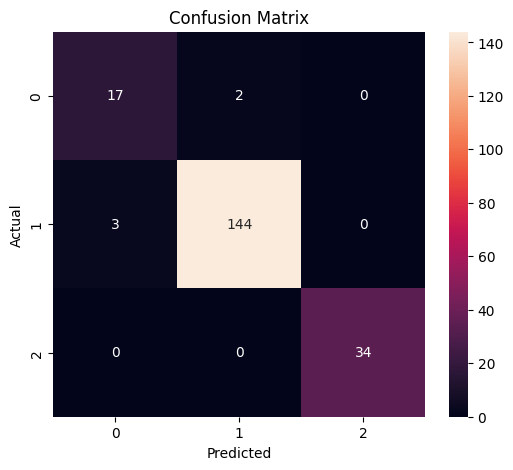

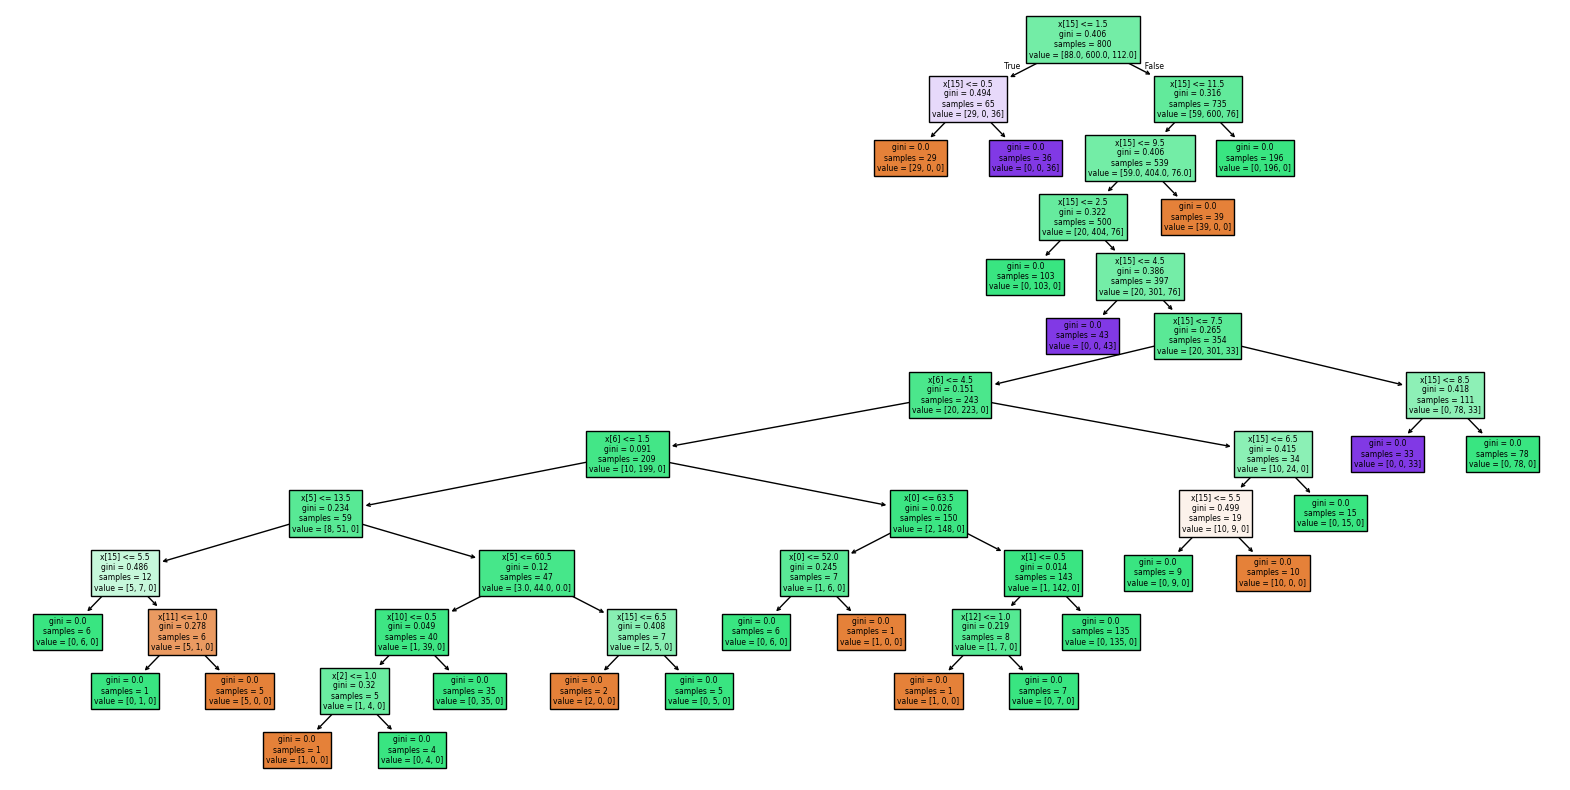

Predicted Action: [1]


In [4]:
import matplotlib.pyplot as plt
from sklearn import tree
import seaborn as sns

# Confusion Matrix Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Decision Tree Visualization
plt.figure(figsize=(20,10))
tree.plot_tree(model, filled=True)
plt.show()

# Sample Prediction
sample = X_test.iloc[0:1]
prediction = model.predict(sample)

print("Predicted Action:", prediction)

In [5]:
import pandas as pd
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False)
print(feature_importance)

                 Feature  Importance
15                Reason    0.952050
6             Task_Layer    0.014826
5              Task_Name    0.009826
0                User_ID    0.006039
12  Total_Day_Load_Hours    0.005391
11              Deadline    0.005134
2           Stress_Level    0.004929
10   Time_Required_Hours    0.001078
1                   Mood    0.000727
7              Task_Type    0.000000
3           Energy_Level    0.000000
4            Sleep_Hours    0.000000
8        Task_Difficulty    0.000000
9               Priority    0.000000
13            Overloaded    0.000000
14           Mood_Impact    0.000000


In [6]:
sample_input = X_test.iloc[5:6]
print("Input Scenario:")
print(sample_input)

prediction = model.predict(sample_input)
print("Predicted Action:")
print(prediction)

actual = y_test.iloc[5]
print("Actual Action:")
print(actual)

Input Scenario:
     User_ID  Mood  Stress_Level  Energy_Level  Sleep_Hours  Task_Name  \
678      644     3             4             6            8         20   

     Task_Layer  Task_Type  Task_Difficulty  Priority  Time_Required_Hours  \
678           5          2                1         1                    2   

     Deadline  Total_Day_Load_Hours  Overloaded  Mood_Impact  Reason  
678         2                     3           0            0       3  
Predicted Action:
[2]
Actual Action:
2


In [7]:
import joblib
joblib.dump(model, 'layer24_model.pkl')
print("Model Saved Successfully")

encoders = {}
from sklearn.preprocessing import LabelEncoder
for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le
joblib.dump(encoders, 'label_encoders.pkl')
print("Encoders Saved Successfully")

Model Saved Successfully
Encoders Saved Successfully


In [8]:
!pip install ipywidgets pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 103.0 MB/s eta 0:00:00


In [9]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# =========================
# CLEAN GLOBAL STYLE
# =========================

display(HTML("""

<style>

body{
    font-family:'Comic Sans MS', 'Trebuchet MS', sans-serif;
}

/* LABELS */
.widget-label{
    font-size:14px !important;
    font-weight:600 !important;
    color:#444 !important;
}

/* INPUT BOXES */
select, input{
    border-radius:20px !important;
    border:1px solid #d6d6d6 !important;
    padding:6px !important;
    font-family:'Comic Sans MS', sans-serif !important;
    font-size:13px !important;
}

/* BUTTONS */
.widget-button{
    border-radius:25px !important;
    font-size:13px !important;
    font-weight:600 !important;
}

/* SLIDER REMOVE LOOK */
.widget-slider{
    display:none !important;
}

</style>

"""))

# =========================
# HEADER
# =========================

display(HTML("""

<div style="
background:#f7d6de;
padding:18px;
border-radius:25px;
text-align:center;
margin-bottom:15px;
">

<h1 style="
font-size:28px;
color:#6a1b9a;
margin:0;
">
🧠 Layer24
</h1>

<p style="
font-size:14px;
color:#333;
margin-top:5px;
">
Emotion-Aware Intelligent Productivity Balancer
</p>

</div>

"""))

# =========================
# USER STATE
# =========================

display(HTML("""

<div style="
background:#f5eef8;
padding:15px;
border-radius:20px;
margin-bottom:12px;
">

<h3 style="
font-size:18px;
color:#6a1b9a;
margin-bottom:10px;
">
👤 User State
</h3>

</div>

"""))

mood = widgets.Dropdown(
    options=[
        "Happy","Neutral","Stressed",
        "Exhausted","Motivated",
        "Relaxed","Anxious",
        "Sad","Burned Out","Focused"
    ],
    description='Mood:',
    layout=widgets.Layout(width='220px')
)

stress = widgets.Dropdown(
    options=[1,2,3,4,5,6,7,8,9,10],
    description='Stress:',
    layout=widgets.Layout(width='220px')
)

energy = widgets.Dropdown(
    options=[1,2,3,4,5,6,7,8,9,10],
    description='Energy:',
    layout=widgets.Layout(width='220px')
)

sleep = widgets.Dropdown(
    options=[0,1,2,3,4,5,6,7,8,9,10,11,12],
    description='Sleep:',
    layout=widgets.Layout(width='220px')
)

row1 = widgets.HBox(
    [mood, stress, energy, sleep],
    layout=widgets.Layout(gap='15px')
)

display(row1)

# =========================
# TASK ENTRY
# =========================

display(HTML("""

<div style="
background:#edf5ff;
padding:15px;
border-radius:20px;
margin-top:18px;
margin-bottom:12px;
">

<h3 style="
font-size:18px;
color:#1565c0;
margin-bottom:10px;
">
📝 Task Entry
</h3>

</div>

"""))

task_name = widgets.Text(
    placeholder='Enter task',
    description='Task:',
    layout=widgets.Layout(width='250px')
)

task_layer = widgets.Dropdown(
    options=[
        "Education",
        "Career & Work",
        "Health & Fitness",
        "Mental Wellness",
        "Family",
        "Relationships",
        "Household",
        "Personal Growth",
        "Social Life",
        "Finance",
        "Spiritual",
        "Entertainment",
        "Self Care",
        "Travel",
        "Emergency"
    ],
    description='Layer:',
    layout=widgets.Layout(width='250px')
)

task_type = widgets.Dropdown(
    options=[
        "Study","Homework","Exam Preparation",
        "Office Work","Meeting","Presentation",
        "Coding","Research","Cooking",
        "Cleaning","Laundry","Grocery Shopping",
        "Pay Bills","Workout","Yoga",
        "Meditation","Doctor Appointment",
        "Family Time","Friends Outing",
        "Dating","Phone Calls","Gaming",
        "Movies","Music","Reading",
        "Journaling","Prayer","Travel",
        "Sleep","Emergency Work",
        "Content Creation","Job Interview",
        "Skill Learning","Project Work"
    ],
    description='Type:',
    layout=widgets.Layout(width='250px')
)

task_difficulty = widgets.Dropdown(
    options=[
        "Very Easy",
        "Easy",
        "Medium",
        "Hard",
        "Very Hard"
    ],
    description='Difficulty:',
    layout=widgets.Layout(width='250px')
)

priority = widgets.Dropdown(
    options=[1,2,3,4,5],
    description='Priority:',
    layout=widgets.Layout(width='180px')
)

time_required = widgets.Dropdown(
    options=[
        0.5,1,1.5,2,2.5,3,3.5,4,
        4.5,5,5.5,6,6.5,7,7.5,8
    ],
    description='Hours:',
    layout=widgets.Layout(width='180px')
)

deadline = widgets.Dropdown(
    options=[0,1,2,3,4,5,6,7,10,15,20,30],
    description='Deadline:',
    layout=widgets.Layout(width='180px')
)

task_row1 = widgets.HBox(
    [task_name, task_layer, task_type],
    layout=widgets.Layout(gap='12px')
)

task_row2 = widgets.HBox(
    [task_difficulty, priority, time_required, deadline],
    layout=widgets.Layout(gap='12px')
)

display(task_row1)
display(task_row2)

# =========================
# STORAGE
# =========================

tasks = []

output = widgets.Output()

# =========================
# BUTTONS
# =========================

save_button = widgets.Button(
    description='Save Task',
    button_style='success',
    layout=widgets.Layout(width='140px', height='38px')
)

delete_button = widgets.Button(
    description='Delete Last',
    button_style='danger',
    layout=widgets.Layout(width='140px', height='38px')
)

clear_button = widgets.Button(
    description='Clear All',
    button_style='warning',
    layout=widgets.Layout(width='140px', height='38px')
)

button_row = widgets.HBox(
    [save_button, delete_button, clear_button],
    layout=widgets.Layout(gap='12px', margin='15px 0')
)

display(button_row)

# =========================
# REFRESH
# =========================

def refresh_tasks():

    with output:

        clear_output()

        if len(tasks) == 0:

            display(HTML("""
            <p style='color:red;font-size:14px'>
            No Tasks Added
            </p>
            """))

        else:

            df = pd.DataFrame(tasks)

            display(HTML(f"""
            <p style='color:green;font-size:14px'>
            Total Tasks: {len(tasks)}
            </p>
            """))

            display(df)

# =========================
# SAVE
# =========================

def save_task(b):

    if task_name.value.strip() == "":
        return

    task = {
        "Task_Name": task_name.value,
        "Task_Layer": task_layer.value,
        "Task_Type": task_type.value,
        "Task_Difficulty": task_difficulty.value,
        "Priority": priority.value,
        "Time_Required_Hours": time_required.value,
        "Deadline": deadline.value
    }

    tasks.append(task)

    refresh_tasks()

# =========================
# DELETE
# =========================

def delete_task(b):

    if len(tasks) > 0:
        tasks.pop()

    refresh_tasks()

# =========================
# CLEAR
# =========================

def clear_tasks(b):

    tasks.clear()

    refresh_tasks()

save_button.on_click(save_task)
delete_button.on_click(delete_task)
clear_button.on_click(clear_tasks)

display(output)

# =========================
# BALANCER
# =========================

display(HTML("""

<div style="
background:#fff4e6;
padding:15px;
border-radius:20px;
margin-top:20px;
margin-bottom:10px;
">

<h3 style="
font-size:18px;
color:#e65100;
">
⚖️ AI Productivity Balancer
</h3>

</div>

"""))

balance_button = widgets.Button(
    description='Balance My Day',
    button_style='info',
    layout=widgets.Layout(width='180px', height='40px')
)

balance_output = widgets.Output()

display(balance_button)

# =========================
# AI LOGIC
# =========================

def balance_day(b):

    with balance_output:

        clear_output()

        if len(tasks) == 0:

            display(HTML("""
            <p style='color:red'>
            Please add tasks first
            </p>
            """))

            return

        df = pd.DataFrame(tasks)

        total_load = df['Time_Required_Hours'].sum()

        overloaded = total_load > 24

        display(HTML(f"""
        <p style='font-size:15px;color:#1565c0'>
        ⏳ Total Day Load: <b>{total_load} Hours</b>
        </p>
        """))

        if overloaded:

            display(HTML("""
            <p style='color:red'>
            ⚠️ Schedule exceeds 24 hours
            </p>
            """))

        else:

            display(HTML("""
            <p style='color:green'>
            ✅ Schedule balanced
            </p>
            """))

        results = []

        for i, row in df.iterrows():

            action = "KEEP"

            if row['Task_Type'] in [
                'Sleep',
                'Meditation',
                'Prayer',
                'Doctor Appointment',
                'Emergency Work',
                'Family Time'
            ]:

                action = "KEEP"

            elif row['Priority'] >= 4:

                action = "KEEP"

            elif overloaded:

                if row['Task_Type'] in [
                    'Gaming',
                    'Movies'
                ]:

                    action = "DELAY"

                elif row['Task_Type'] in [
                    'Workout',
                    'Yoga',
                    'Music',
                    'Reading'
                ]:

                    action = "REDUCE"

                elif stress.value >= 8 and row['Task_Difficulty'] in [
                    'Hard',
                    'Very Hard'
                ]:

                    action = "REDUCE"

                elif energy.value <= 3 and row['Time_Required_Hours'] >= 5:

                    action = "REDUCE"

            results.append({
                "Task": row['Task_Name'],
                "Suggested_Action": action
            })

        result_df = pd.DataFrame(results)

        display(result_df)

balance_button.on_click(balance_day)

display(balance_output)

Output()

Button(button_style='info', description='Balance My Day', layout=Layout(height='40px', width='180px'), style=B…

Output()